# Notebook 10 — Feature Extraction

> **No training required** — loads `best_model.pth` and extracts encoder bottleneck features from the validation set.

---

## Objectives

- Extract deep features from the SegResNet encoder bottleneck
- Visualize the feature space using PCA and t-SNE
- Analyze what the model has learned per tumor subregion
- Save features as `.npy` for downstream use (multimodal fusion, clustering)

## What are Bottleneck Features?

The SegResNet encoder progressively downsamples the input volume through residual blocks. The deepest encoder layer — the **bottleneck** — produces a compact representation that captures the most abstract, high-level features the model learned to distinguish tumor subregions.

We extract these features using a **forward hook** on the encoder's last layer.

## 1. Setup

### 1.1 Install Dependencies

In [1]:
!pip -q install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.

### 1.2 Imports

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
from torch.utils.data import Dataset, DataLoader

from monai.networks.nets import SegResNet
from monai.inferers import SlidingWindowInferer

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

2026-06-28 15:18:26.239904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782659906.482758      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782659906.554469      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782659907.130902      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782659907.130955      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782659907.130958      23 computation_placer.cc:177] computation placer alr

### 1.3 Paths & Constants

In [3]:
PROCESSED_PATH = Path(
    "/kaggle/input/datasets/mariammohamed1095/workingg/datasets/processed/cv"
)

CHECKPOINT_PATH = Path(
    "/kaggle/input/models/mariammohamed1095/brats2020-segresnet/pytorch/default/1/models/segmentation/best_model.pth"
)

RESULT_DIR = Path("/kaggle/working/reports/results")
FIGURE_DIR = Path("/kaggle/working/reports/figures")

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load Model

### 2.1 Build and Load SegResNet

In [4]:
model = SegResNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    init_filters=32,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(device)

state_dict = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(state_dict)
model.eval()

print("Checkpoint loaded.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Checkpoint loaded.
Parameters: 18,798,660


### 2.2 Register Forward Hook on Bottleneck

The SegResNet encoder ends at `model.down_layers[-1]`.
We register a hook that captures the output of this layer during the forward pass — without modifying the model or the inference pipeline.

In [5]:
bottleneck_features = {}

def hook_fn(module, input, output):
    # output shape: (B, C, D, H, W)
    # Global average pool → (B, C) compact representation
    bottleneck_features["encoding"] = output.detach().mean(dim=[2, 3, 4])

hook = model.down_layers[-1].register_forward_hook(hook_fn)

print("Hook registered on:", model.down_layers[-1].__class__.__name__)

Hook registered on: Sequential


## 3. Dataset

In [6]:
class PreprocessedDataset(torch.utils.data.Dataset):

    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.files    = sorted(self.root_dir.glob("*.pt"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        sample = torch.load(self.files[index], weights_only=False)
        return {
            "image":      sample["image"],
            "label":      sample["label"],
            "patient_id": sample["patient_id"],
        }


val_dataset = PreprocessedDataset(PROCESSED_PATH / "validation")
val_loader  = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

print("Validation patients:", len(val_dataset))

Validation patients: 56


## 4. Extract Features

### 4.1 Extraction Loop

In [7]:
all_features    = []
all_patient_ids = []
all_wt_volume   = []
all_et_volume   = []
all_tc_volume   = []


def pad_and_crop_128(image: torch.Tensor) -> torch.Tensor:
    """
    Pad to at least 128 in each spatial dim, then center crop to exactly
    (128, 128, 128). Pure PyTorch — no MONAI transforms needed.

    Parameters
    ----------
    image : torch.Tensor  shape (4, D, H, W)

    Returns
    -------
    torch.Tensor  shape (4, 128, 128, 128)
    """
    C, D, H, W = image.shape
    target = 128

    # ── Pad ──────────────────────────────────────────────────────────────────
    pad_d = max(target - D, 0)
    pad_h = max(target - H, 0)
    pad_w = max(target - W, 0)

    # F.pad pads last dims first: (W_left, W_right, H_left, H_right, D_left, D_right)
    image = torch.nn.functional.pad(
        image,
        (
            pad_w // 2, pad_w - pad_w // 2,
            pad_h // 2, pad_h - pad_h // 2,
            pad_d // 2, pad_d - pad_d // 2,
        ),
        mode="constant",
        value=0,
    )

    # ── Center crop ──────────────────────────────────────────────────────────
    _, D2, H2, W2 = image.shape

    d0 = (D2 - target) // 2
    h0 = (H2 - target) // 2
    w0 = (W2 - target) // 2

    return image[:, d0:d0+target, h0:h0+target, w0:w0+target]


with torch.no_grad():

    for i, batch in enumerate(val_loader):

        patient_id = batch["patient_id"][0]
        label      = batch["label"].squeeze().numpy()

        image = batch["image"][0]                    # (4, D, H, W)
        patch = pad_and_crop_128(image).unsqueeze(0).to(device)  # (1, 4, 128, 128, 128)

        # Direct forward pass — hook captures bottleneck activation
        _ = model(patch)

        features = bottleneck_features["encoding"].cpu().numpy()   # (1, C)
        all_features.append(features[0])
        all_patient_ids.append(patient_id)

        all_wt_volume.append(int((label > 0).sum()))
        all_tc_volume.append(int(((label == 1) | (label == 3)).sum()))
        all_et_volume.append(int((label == 3).sum()))

        if (i + 1) % 10 == 0 or (i + 1) == len(val_loader):
            print(f"  [{i+1:02d}/{len(val_loader)}] {patient_id} — feature dim: {features.shape[1]}")

hook.remove()   # always remove hook after use

features_matrix = np.array(all_features)   # (N, C)
print(f"\nFeature matrix shape: {features_matrix.shape}")

  [10/56] BraTS20_Training_071 — feature dim: 256
  [20/56] BraTS20_Training_105 — feature dim: 256
  [30/56] BraTS20_Training_152 — feature dim: 256
  [40/56] BraTS20_Training_247 — feature dim: 256
  [50/56] BraTS20_Training_322 — feature dim: 256
  [56/56] BraTS20_Training_361 — feature dim: 256

Feature matrix shape: (56, 256)


### 4.2 Save Raw Features

In [8]:
np.save(RESULT_DIR / "bottleneck_features.npy", features_matrix)

meta_df = pd.DataFrame({
    "patient_id": all_patient_ids,
    "wt_volume":  all_wt_volume,
    "tc_volume":  all_tc_volume,
    "et_volume":  all_et_volume,
})
meta_df.to_csv(RESULT_DIR / "feature_metadata.csv", index=False)

print("Saved:")
print(f"  {RESULT_DIR / 'bottleneck_features.npy'}  shape: {features_matrix.shape}")
print(f"  {RESULT_DIR / 'feature_metadata.csv'}")

Saved:
  /kaggle/working/reports/results/bottleneck_features.npy  shape: (56, 256)
  /kaggle/working/reports/results/feature_metadata.csv


## 5. Feature Statistics

### 5.1 Descriptive Statistics per Dimension

Analyze the distribution of the bottleneck feature vector across all validation patients.

In [9]:
# Per-dimension statistics across all patients
feat_mean = features_matrix.mean(axis=0)   # (C,)
feat_std  = features_matrix.std(axis=0)    # (C,)
feat_min  = features_matrix.min(axis=0)
feat_max  = features_matrix.max(axis=0)

print(f"Feature dimensions : {features_matrix.shape[1]}")
print(f"Patients           : {features_matrix.shape[0]}")
print()
print(f"Global mean  : {feat_mean.mean():.4f}")
print(f"Global std   : {feat_std.mean():.4f}")
print(f"Global min   : {feat_min.min():.4f}")
print(f"Global max   : {feat_max.max():.4f}")

Feature dimensions : 256
Patients           : 56

Global mean  : 1.7285
Global std   : 1.1286
Global min   : -25.1077
Global max   : 24.4125


### 5.2 Feature Distribution Plot

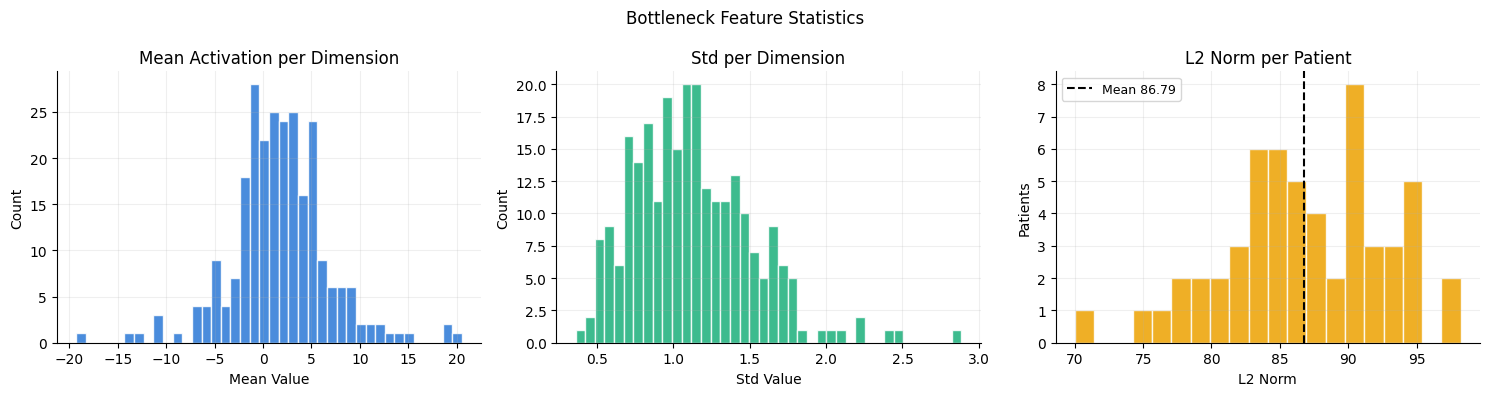

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of mean activation per dimension
axes[0].hist(feat_mean, bins=40, color="#2a78d6", alpha=0.85, edgecolor="white")
axes[0].set_title("Mean Activation per Dimension")
axes[0].set_xlabel("Mean Value")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2)
axes[0].spines[["top","right"]].set_visible(False)

# Distribution of std per dimension
axes[1].hist(feat_std, bins=40, color="#1baf7a", alpha=0.85, edgecolor="white")
axes[1].set_title("Std per Dimension")
axes[1].set_xlabel("Std Value")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)
axes[1].spines[["top","right"]].set_visible(False)

# L2 norm per patient
l2_norms = np.linalg.norm(features_matrix, axis=1)
axes[2].hist(l2_norms, bins=20, color="#eda100", alpha=0.85, edgecolor="white")
axes[2].axvline(l2_norms.mean(), color="black", linestyle="--", linewidth=1.5,
                label=f"Mean {l2_norms.mean():.2f}")
axes[2].set_title("L2 Norm per Patient")
axes[2].set_xlabel("L2 Norm")
axes[2].set_ylabel("Patients")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.2)
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("Bottleneck Feature Statistics", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_statistics.png", dpi=150)
plt.show()

## 6. Dimensionality Reduction

### 6.1 PCA

In [11]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_matrix)

pca = PCA(n_components=2, random_state=42)
features_pca = pca.fit_transform(features_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}  |  PC2: {pca.explained_variance_ratio_[1]:.3f}")

PCA explained variance: 0.541
PC1: 0.293  |  PC2: 0.248


### 6.2 t-SNE

In [12]:
tsne = TSNE(n_components=2, perplexity=15, random_state=42, max_iter=1000)
features_tsne = tsne.fit_transform(features_scaled)

print("t-SNE complete. Shape:", features_tsne.shape)

t-SNE complete. Shape: (56, 2)


## 7. Cosine Similarity Analysis

Measures how similar patients are in the bottleneck feature space.
High cosine similarity → the model's encoder produces similar representations for these patients.
This can reveal patient clusters with similar tumor characteristics.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise cosine similarity matrix (N x N)
cos_sim_matrix = cosine_similarity(features_matrix)

print(f"Similarity matrix shape : {cos_sim_matrix.shape}")
print(f"Mean similarity         : {cos_sim_matrix.mean():.4f}")
print(f"Std similarity          : {cos_sim_matrix.std():.4f}")
print()

# Exclude self-similarity (diagonal = 1.0)
np.fill_diagonal(cos_sim_matrix, np.nan)

print(f"Mean inter-patient similarity : {np.nanmean(cos_sim_matrix):.4f}")
print(f"Min similarity                : {np.nanmin(cos_sim_matrix):.4f}")
print(f"Max similarity                : {np.nanmax(cos_sim_matrix):.4f}")

Similarity matrix shape : (56, 56)
Mean similarity         : 0.9566
Std similarity          : 0.0282

Mean inter-patient similarity : 0.9558
Min similarity                : 0.8291
Max similarity                : 0.9983


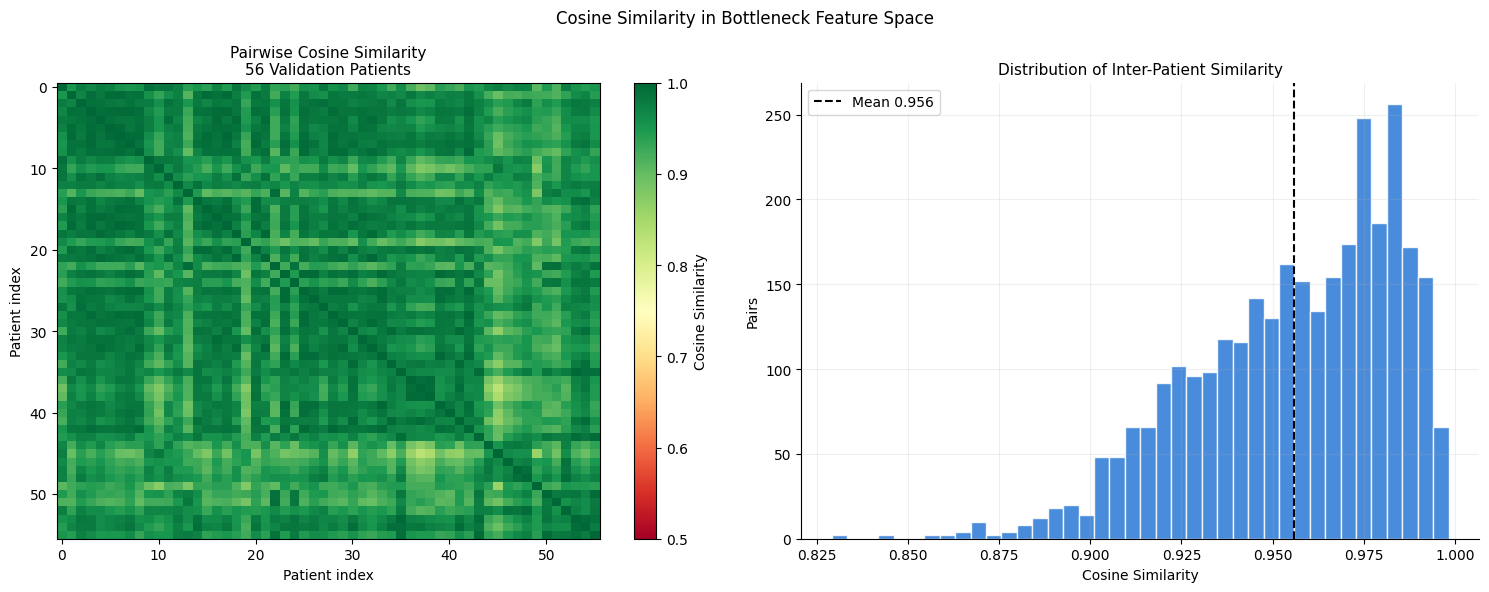

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
np.fill_diagonal(cos_sim_matrix, 1.0)  # restore diagonal for heatmap
im = axes[0].imshow(cos_sim_matrix, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")
plt.colorbar(im, ax=axes[0], label="Cosine Similarity")
axes[0].set_title(f"Pairwise Cosine Similarity\n{len(all_patient_ids)} Validation Patients", fontsize=11)
axes[0].set_xlabel("Patient index")
axes[0].set_ylabel("Patient index")

# Distribution of off-diagonal similarities
np.fill_diagonal(cos_sim_matrix, np.nan)
off_diag = cos_sim_matrix[~np.isnan(cos_sim_matrix)].flatten()

axes[1].hist(off_diag, bins=40, color="#2a78d6", alpha=0.85, edgecolor="white")
axes[1].axvline(np.nanmean(cos_sim_matrix), color="black", linestyle="--", linewidth=1.5,
                label=f"Mean {np.nanmean(cos_sim_matrix):.3f}")
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Pairs")
axes[1].set_title("Distribution of Inter-Patient Similarity", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.2)
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("Cosine Similarity in Bottleneck Feature Space", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_cosine_similarity.png", dpi=150)
plt.show()

In [15]:
# Most and least similar patient pairs
np.fill_diagonal(cos_sim_matrix, np.nan)
patient_ids = all_patient_ids

flat_sim = []
n = len(patient_ids)
for i in range(n):
    for j in range(i+1, n):
        flat_sim.append((patient_ids[i], patient_ids[j], cos_sim_matrix[i, j]))

flat_sim.sort(key=lambda x: x[2], reverse=True)

print("Top 5 most similar patient pairs:")
for a, b, s in flat_sim[:5]:
    print(f"  {a} ↔ {b}  sim={s:.4f}")

print()
print("Top 5 least similar patient pairs:")
for a, b, s in flat_sim[-5:]:
    print(f"  {a} ↔ {b}  sim={s:.4f}")

Top 5 most similar patient pairs:
  BraTS20_Training_104 ↔ BraTS20_Training_112  sim=0.9983
  BraTS20_Training_176 ↔ BraTS20_Training_344  sim=0.9976
  BraTS20_Training_150 ↔ BraTS20_Training_270  sim=0.9974
  BraTS20_Training_168 ↔ BraTS20_Training_247  sim=0.9963
  BraTS20_Training_112 ↔ BraTS20_Training_166  sim=0.9963

Top 5 least similar patient pairs:
  BraTS20_Training_260 ↔ BraTS20_Training_293  sim=0.8642
  BraTS20_Training_200 ↔ BraTS20_Training_293  sim=0.8598
  BraTS20_Training_293 ↔ BraTS20_Training_322  sim=0.8579
  BraTS20_Training_222 ↔ BraTS20_Training_293  sim=0.8421
  BraTS20_Training_204 ↔ BraTS20_Training_293  sim=0.8291


## 8. Visualization

### 7.1 PCA — Colored by WT Volume

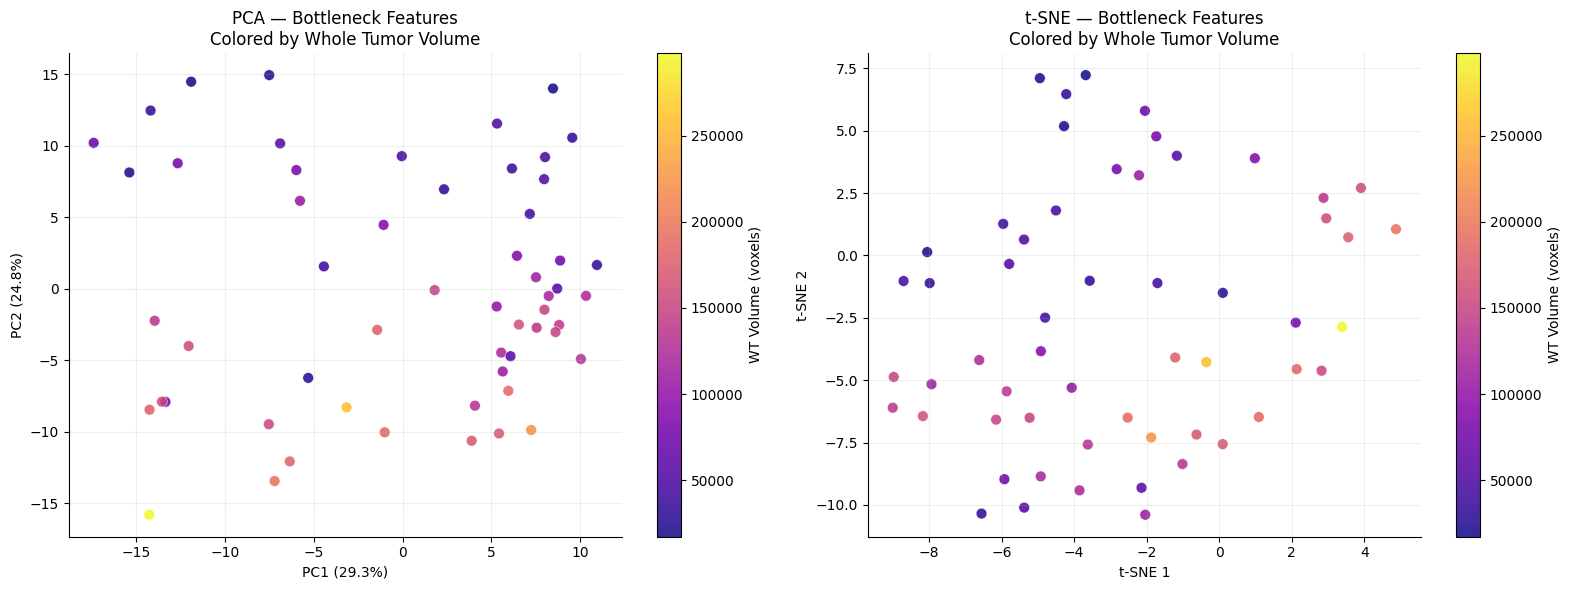

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wt_volumes = np.array(all_wt_volume)
tc_volumes = np.array(all_tc_volume)
et_volumes = np.array(all_et_volume)

# PCA
sc = axes[0].scatter(
    features_pca[:, 0], features_pca[:, 1],
    c=wt_volumes, cmap="plasma", s=60, alpha=0.85, edgecolors="white", linewidths=0.4
)
plt.colorbar(sc, ax=axes[0], label="WT Volume (voxels)")
axes[0].set_title("PCA — Bottleneck Features\nColored by Whole Tumor Volume", fontsize=12)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].grid(alpha=0.2)
axes[0].spines[["top", "right"]].set_visible(False)

# t-SNE
sc2 = axes[1].scatter(
    features_tsne[:, 0], features_tsne[:, 1],
    c=wt_volumes, cmap="plasma", s=60, alpha=0.85, edgecolors="white", linewidths=0.4
)
plt.colorbar(sc2, ax=axes[1], label="WT Volume (voxels)")
axes[1].set_title("t-SNE — Bottleneck Features\nColored by Whole Tumor Volume", fontsize=12)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.2)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_pca_tsne_wt.png", dpi=150)
plt.show()


### 7.2 PCA — Colored by ET Volume

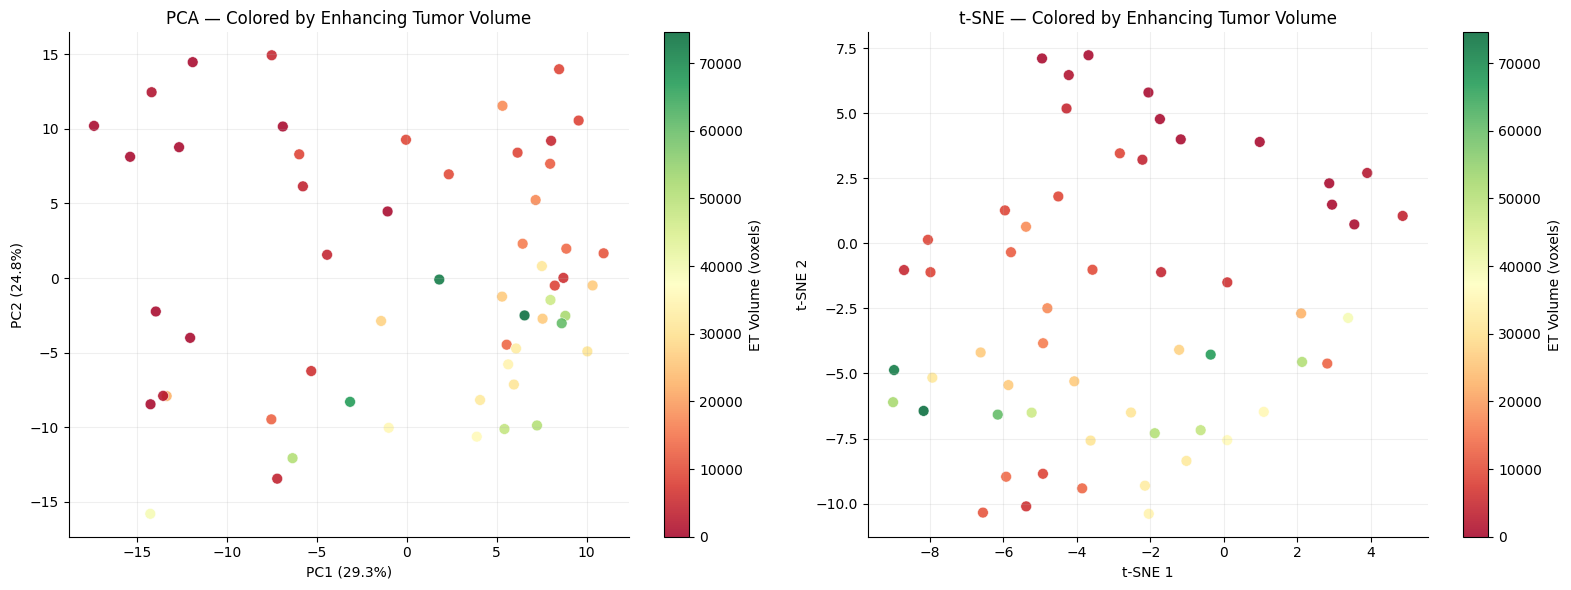

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(
    features_pca[:, 0], features_pca[:, 1],
    c=et_volumes, cmap="RdYlGn", s=60, alpha=0.85, edgecolors="white", linewidths=0.4
)
plt.colorbar(sc, ax=axes[0], label="ET Volume (voxels)")
axes[0].set_title("PCA — Colored by Enhancing Tumor Volume", fontsize=12)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].grid(alpha=0.2)
axes[0].spines[["top", "right"]].set_visible(False)

sc2 = axes[1].scatter(
    features_tsne[:, 0], features_tsne[:, 1],
    c=et_volumes, cmap="RdYlGn", s=60, alpha=0.85, edgecolors="white", linewidths=0.4
)
plt.colorbar(sc2, ax=axes[1], label="ET Volume (voxels)")
axes[1].set_title("t-SNE — Colored by Enhancing Tumor Volume", fontsize=12)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.2)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_pca_tsne_et.png", dpi=150)
plt.show()

### 7.3 PCA Variance Explained

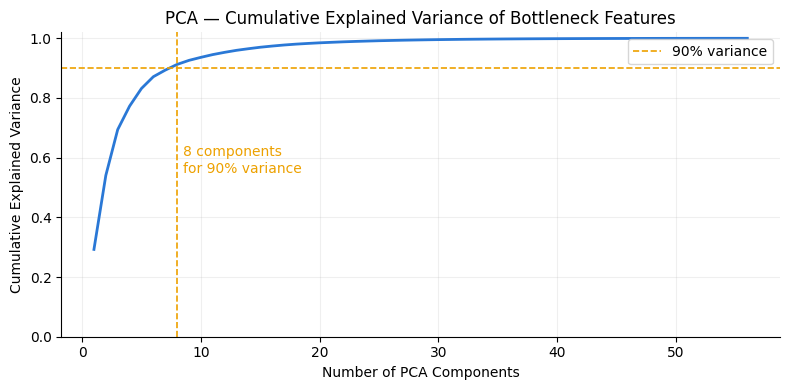

Components needed for 90% variance: 8


In [18]:
pca_full = PCA(random_state=42).fit(features_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n90      = int(np.searchsorted(cumvar, 0.90)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, color="#2a78d6", linewidth=2)
ax.axhline(0.90, color="#eda100", linestyle="--", linewidth=1.2, label="90% variance")
ax.axvline(n90,  color="#eda100", linestyle="--", linewidth=1.2)
ax.text(n90+0.5, 0.55, f"{n90} components\nfor 90% variance", color="#eda100", fontsize=10)
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA — Cumulative Explained Variance of Bottleneck Features")
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_pca_variance.png", dpi=150)
plt.show()

print(f"Components needed for 90% variance: {n90}")


### 7.4 Feature Correlation with Tumor Volume

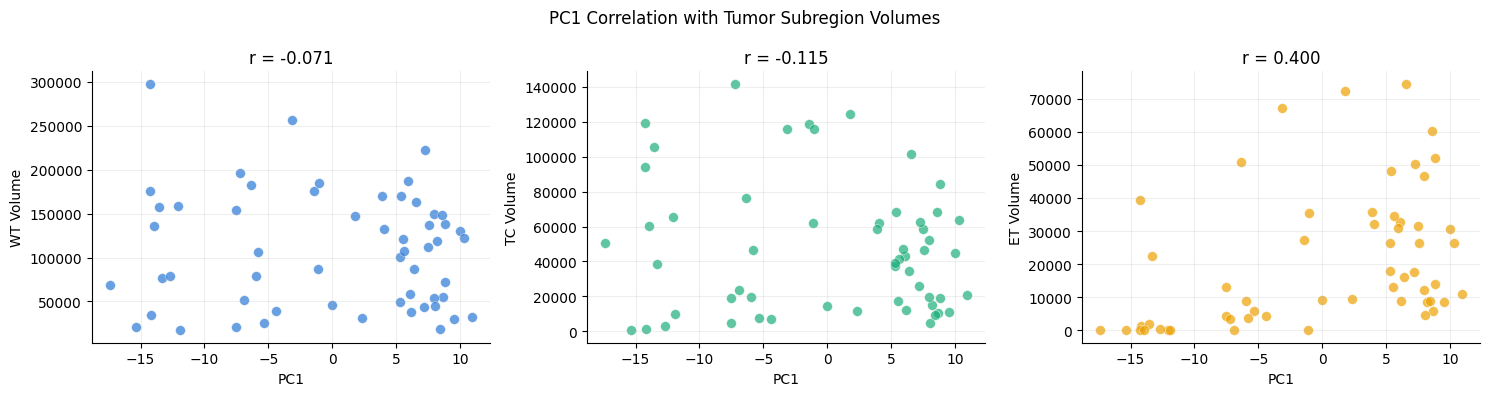

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ("PC1", features_pca[:, 0], "WT Volume", wt_volumes, "#2a78d6"),
    ("PC1", features_pca[:, 0], "TC Volume", tc_volumes, "#1baf7a"),
    ("PC1", features_pca[:, 0], "ET Volume", et_volumes, "#eda100"),
]

for ax, (xlab, xdata, ylab, ydata, color) in zip(axes, pairs):
    ax.scatter(xdata, ydata, color=color, s=50, alpha=0.7, edgecolors="white", linewidths=0.4)
    corr = np.corrcoef(xdata, ydata)[0, 1]
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f"r = {corr:.3f}", fontsize=12)
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("PC1 Correlation with Tumor Subregion Volumes", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_correlation.png", dpi=150)
plt.show()

## 9. `extract_image_features()` API

A clean, reusable function that wraps the full feature extraction pipeline.
This is the stable interface referenced in `predict.py` and usable in downstream notebooks.

In [20]:
def extract_image_features(
    model: torch.nn.Module,
    image: torch.Tensor,
    device: torch.device,
) -> np.ndarray:
    """
    Extract bottleneck features from a preprocessed MRI volume.

    Pads to at least 128³ then center crops to exactly 128³ using
    pure PyTorch (no MONAI transforms) before the forward pass.

    Parameters
    ----------
    model  : SegResNet in eval() mode, already on device
    image  : torch.Tensor  shape (1, 4, D, H, W) — preprocessed MRI
    device : torch.device

    Returns
    -------
    np.ndarray  shape (C,)  — bottleneck feature vector
    """

    captured = {}

    def _hook(module, input, output):
        captured["features"] = output.detach().mean(dim=[2, 3, 4])

    hook = model.down_layers[-1].register_forward_hook(_hook)

    patch = pad_and_crop_128(image[0]).unsqueeze(0).to(device)  # (1, 4, 128, 128, 128)

    model.eval()
    with torch.no_grad():
        _ = model(patch)

    hook.remove()

    return captured["features"][0].cpu().numpy()   # (C,)

### 9.1 Test the API on One Patient

In [21]:
# Load one patient
sample = torch.load(
    sorted((PROCESSED_PATH / "validation").glob("*.pt"))[0],
    weights_only=False,
)

image = sample["image"].unsqueeze(0)  # (1, 4, D, H, W)

features_single = extract_image_features(model, image, device)

print(f"Patient    : {sample['patient_id']}")
print(f"Image shape: {image.shape}")
print(f"Feature dim: {features_single.shape}")
print(f"L2 norm    : {np.linalg.norm(features_single):.4f}")

Patient    : BraTS20_Training_009
Image shape: torch.Size([1, 4, 106, 134, 91])
Feature dim: (256,)
L2 norm    : 88.8136


## 10. Summary

## 11. Feature Norm Table

Per-patient statistics over the bottleneck feature vector.
Saved as `feature_norm_table.csv` for downstream analysis.

In [22]:
norm_records = []

for pid, feat in zip(all_patient_ids, all_features):
    norm_records.append({
        "patient_id":    pid,
        "feature_mean":  float(feat.mean()),
        "feature_std":   float(feat.std()),
        "feature_min":   float(feat.min()),
        "feature_max":   float(feat.max()),
        "l2_norm":       float(np.linalg.norm(feat)),
    })

norm_df = pd.DataFrame(norm_records)
norm_df.to_csv(RESULT_DIR / "feature_norm_table.csv", index=False)

print(norm_df.round(4).to_string(index=False))

          patient_id  feature_mean  feature_std  feature_min  feature_max  l2_norm
BraTS20_Training_009        1.3908       5.3738     -21.7159      21.5775  88.8136
BraTS20_Training_011        1.3882       4.5184     -17.0044      16.2748  75.6293
BraTS20_Training_020        1.8849       5.3773     -20.6650      22.1665  91.1698
BraTS20_Training_038        1.7738       4.9389     -19.2309      19.2915  83.9639
BraTS20_Training_047        1.5270       5.0569     -19.7385      19.6115  84.5182
BraTS20_Training_051        1.4373       4.8607     -18.9613      18.1404  81.0996
BraTS20_Training_055        1.5446       4.5931     -16.9126      17.2889  77.5331
BraTS20_Training_060        1.7751       4.8280     -18.1705      19.1970  82.3042
BraTS20_Training_067        1.6377       4.7965     -17.1556      18.4606  81.0943
BraTS20_Training_071        1.2468       5.5245     -21.1349      22.0590  90.6150
BraTS20_Training_074        1.3272       5.7832     -22.7256      22.1746  94.9371
BraT

## 12. Top Activated Channels

Identify the 20 most active feature dimensions across all patients.
These are the channels the encoder relies on most — commonly reported in medical imaging papers.

In [23]:
# Mean activation per channel across all patients
channel_means = features_matrix.mean(axis=0)   # (C,)
channel_stds  = features_matrix.std(axis=0)    # (C,)

top20_idx  = np.argsort(channel_means)[::-1][:20]
top20_mean = channel_means[top20_idx]
top20_std  = channel_stds[top20_idx]

top20_df = pd.DataFrame({
    "channel_idx":  top20_idx,
    "mean_activation": top20_mean.round(4),
    "std_activation":  top20_std.round(4),
})
top20_df.to_csv(RESULT_DIR / "top20_channels.csv", index=False)

print("Top 20 most activated channels:")
print(top20_df.to_string(index=False))

Top 20 most activated channels:
 channel_idx  mean_activation  std_activation
          61        20.546700          2.2321
          82        18.878599          1.6544
          59        18.614901          1.1158
          50        14.840200          1.6502
          52        13.670900          1.8073
          36        13.146700          2.2308
         183        12.520000          0.8498
         152        12.496500          1.3209
          12        11.164600          0.9161
          31        10.865100          1.1441
         176         9.997200          1.1241
         158         9.897500          1.5511
          66         9.418800          0.7681
         242         9.294100          1.5179
         155         9.179200          1.7311
         224         9.156500          1.0857
           6         8.985100          1.2860
         167         8.738900          1.2908
          92         8.554600          1.2009
          34         8.319200          1.4652


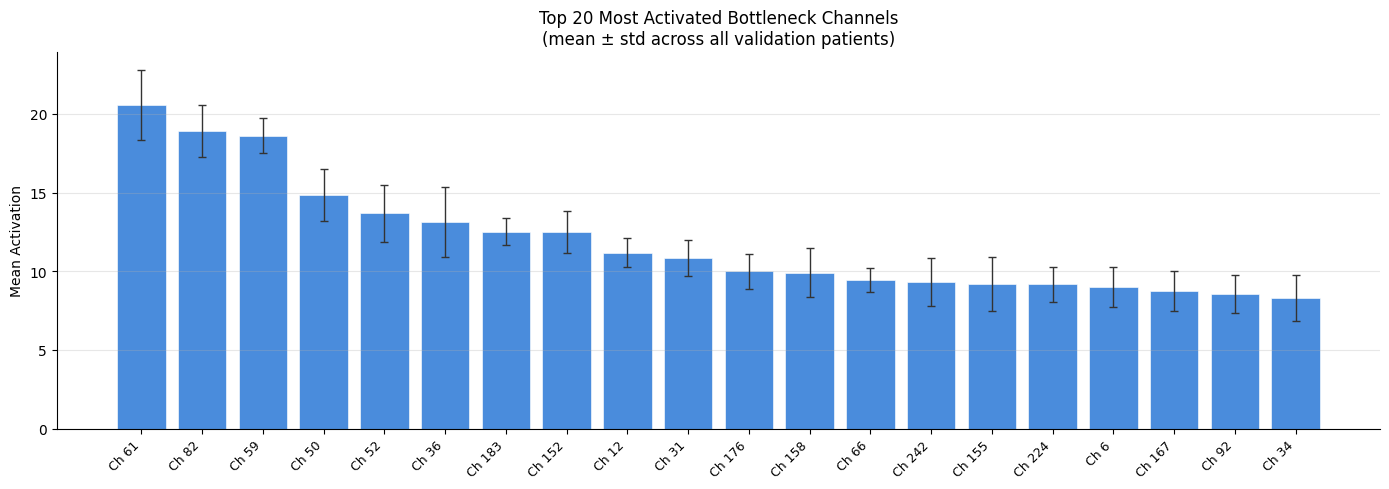

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    range(20), top20_mean,
    yerr=top20_std,
    color="#2a78d6", alpha=0.85,
    edgecolor="white", linewidth=0.5,
    error_kw=dict(elinewidth=1, ecolor="#333", capsize=3),
)
ax.set_xticks(range(20))
ax.set_xticklabels([f"Ch {idx}" for idx in top20_idx], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean Activation")
ax.set_title("Top 20 Most Activated Bottleneck Channels\n(mean ± std across all validation patients)", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "top20_channels.png", dpi=150)
plt.show()


## 13. Feature Importance Heatmap

Heatmap of bottleneck activations: rows = patients, columns = top 40 channels.
Reveals which patients share similar encoder representations.

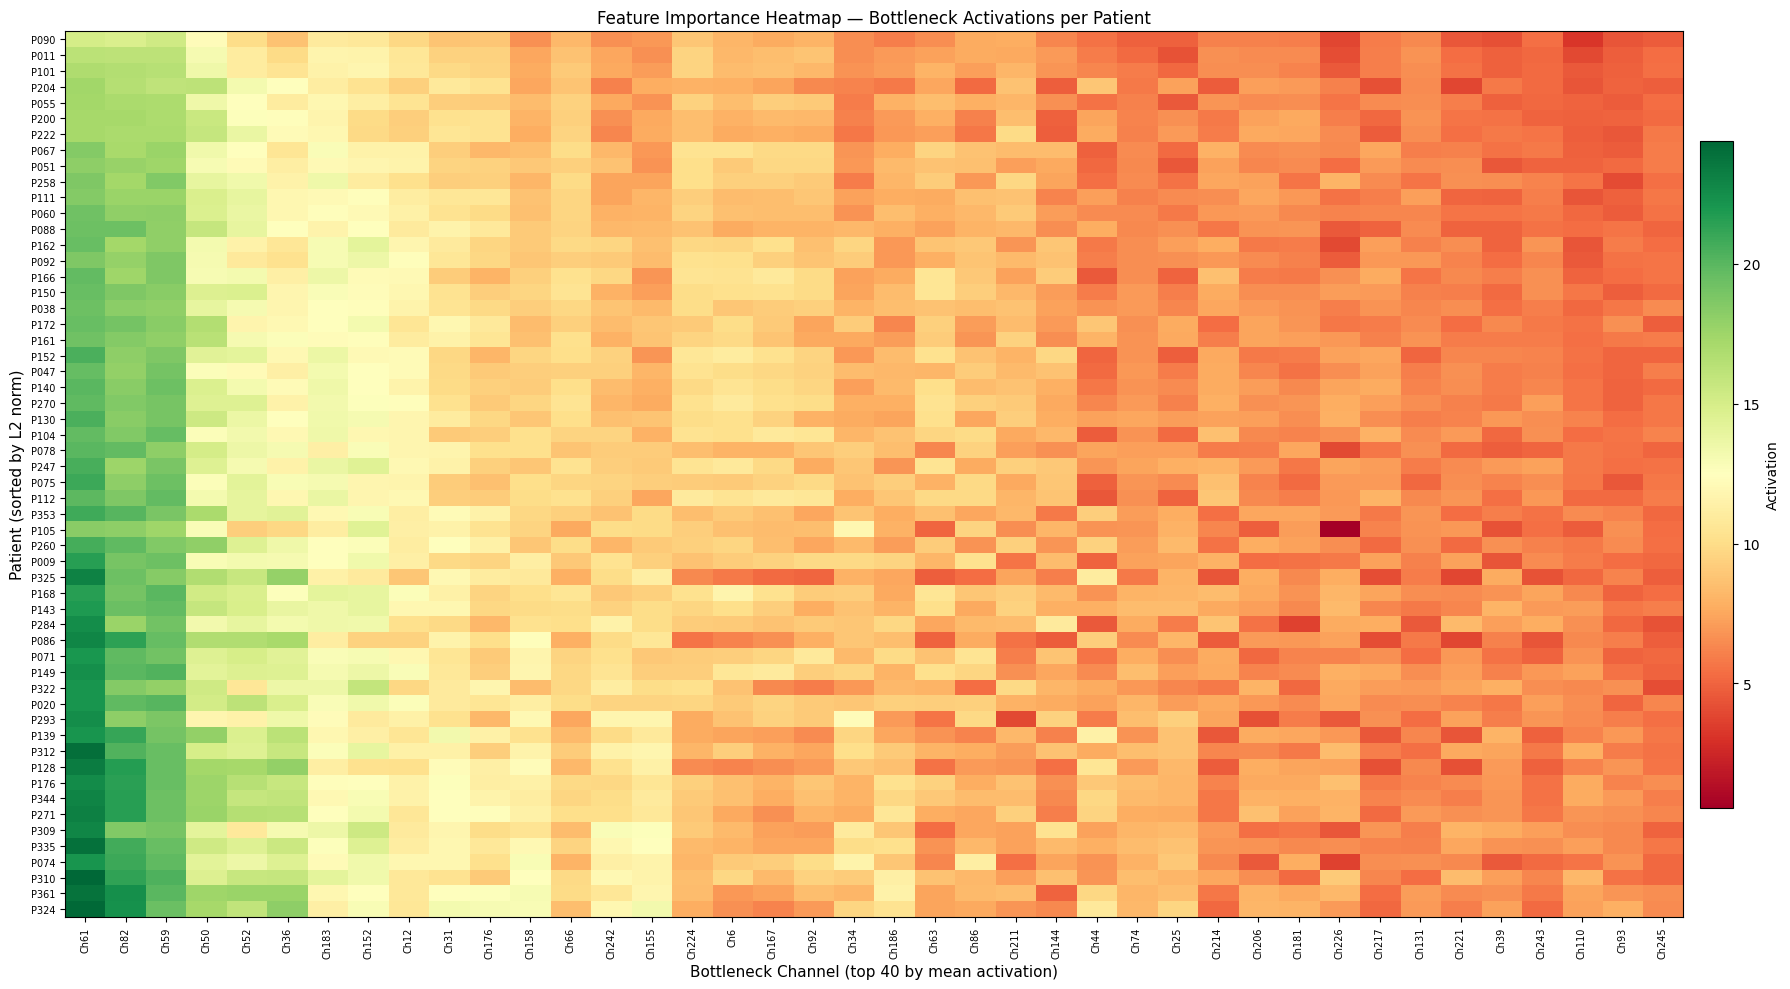

In [25]:
# Select top 40 channels by mean activation for the heatmap
top40_idx = np.argsort(channel_means)[::-1][:40]
heatmap_data = features_matrix[:, top40_idx]   # (N, 40)

# Sort patients by L2 norm for cleaner visual ordering
sort_order   = np.argsort(norm_df["l2_norm"].values)
heatmap_data = heatmap_data[sort_order]
sorted_ids   = [all_patient_ids[i] for i in sort_order]

fig, ax = plt.subplots(figsize=(18, 10))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdYlGn",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label="Activation", fraction=0.02, pad=0.01)

ax.set_xticks(range(40))
ax.set_xticklabels([f"Ch{idx}" for idx in top40_idx], rotation=90, fontsize=7)
ax.set_yticks(range(len(sorted_ids)))
ax.set_yticklabels(
    [pid.replace("BraTS20_Training_", "P") for pid in sorted_ids],
    fontsize=7
)
ax.set_xlabel("Bottleneck Channel (top 40 by mean activation)", fontsize=11)
ax.set_ylabel("Patient (sorted by L2 norm)", fontsize=11)
ax.set_title("Feature Importance Heatmap — Bottleneck Activations per Patient", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_importance_heatmap.png", dpi=150)
plt.show()

## 14. Feature Retrieval — Similar Patient Search

Given a query patient, find the 5 most similar patients in the bottleneck feature space using cosine similarity.

```
Query Patient
      ↓
Cosine Similarity vs all others
      ↓
Top 5 most similar patients
```

In [26]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def find_similar_patients(
    query_patient_id: str,
    features_matrix:  np.ndarray,
    patient_ids:      list,
    top_k:            int = 5,
) -> pd.DataFrame:
    """
    Find the top_k most similar patients to a query patient
    using cosine similarity in bottleneck feature space.

    Parameters
    ----------
    query_patient_id : str
    features_matrix  : np.ndarray  (N, C)
    patient_ids      : list of str
    top_k            : int

    Returns
    -------
    pd.DataFrame with columns: rank, patient_id, cosine_similarity
    """
    if query_patient_id not in patient_ids:
        raise ValueError(f"{query_patient_id} not found in patient list.")

    query_idx     = patient_ids.index(query_patient_id)
    query_feat    = features_matrix[query_idx].reshape(1, -1)

    similarities  = cos_sim(query_feat, features_matrix)[0]   # (N,)
    similarities[query_idx] = -1   # exclude self

    top_indices   = np.argsort(similarities)[::-1][:top_k]

    return pd.DataFrame({
        "rank":               range(1, top_k + 1),
        "patient_id":         [patient_ids[i] for i in top_indices],
        "cosine_similarity":  [similarities[i] for i in top_indices],
    })

In [27]:
# ── Demo: query the first patient ────────────────────────────────────────────
query_id = all_patient_ids[0]

results = find_similar_patients(
    query_patient_id=query_id,
    features_matrix=features_matrix,
    patient_ids=all_patient_ids,
    top_k=5,
)

print(f"Query patient : {query_id}")
print()
print(results.round(4).to_string(index=False))

Query patient : BraTS20_Training_009

 rank           patient_id  cosine_similarity
    1 BraTS20_Training_071             0.9908
    2 BraTS20_Training_075             0.9854
    3 BraTS20_Training_149             0.9837
    4 BraTS20_Training_104             0.9836
    5 BraTS20_Training_074             0.9835


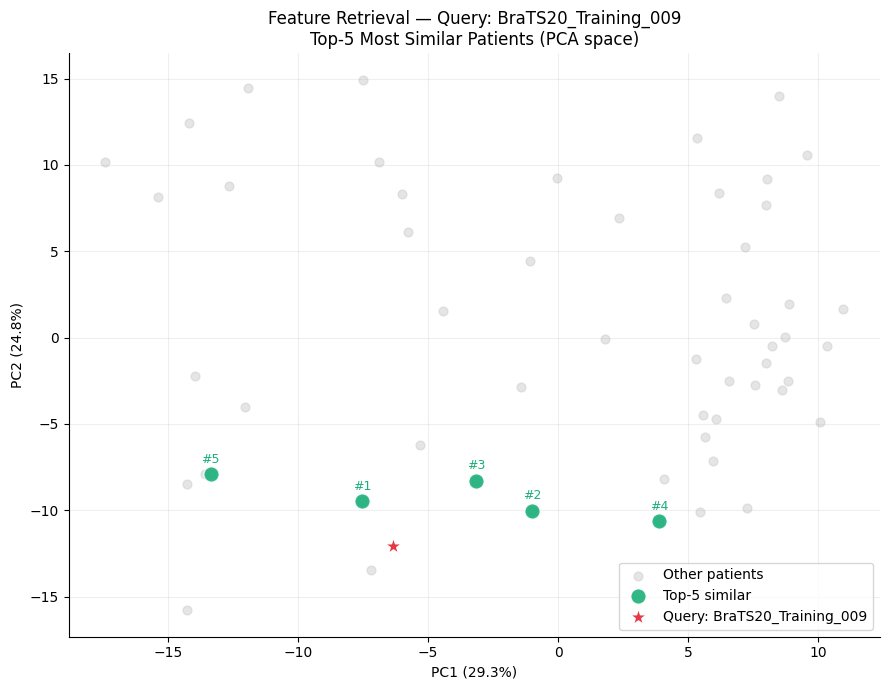

In [28]:
# ── Visualization: query vs top-5 in PCA space ───────────────────────────────
query_idx = all_patient_ids.index(query_id)
top5_ids  = results["patient_id"].tolist()
top5_idxs = [all_patient_ids.index(pid) for pid in top5_ids]

fig, ax = plt.subplots(figsize=(9, 7))

# All patients — background
ax.scatter(
    features_pca[:, 0], features_pca[:, 1],
    color="#cccccc", s=40, alpha=0.5, label="Other patients", zorder=1
)

# Top-5 similar
ax.scatter(
    features_pca[top5_idxs, 0], features_pca[top5_idxs, 1],
    color="#1baf7a", s=120, alpha=0.9, label="Top-5 similar", zorder=3,
    edgecolors="white", linewidths=0.8
)
for rank, idx in enumerate(top5_idxs, 1):
    ax.annotate(
        f"#{rank}",
        (features_pca[idx, 0], features_pca[idx, 1]),
        fontsize=9, ha="center", va="bottom",
        xytext=(0, 6), textcoords="offset points", color="#1baf7a"
    )

# Query patient
ax.scatter(
    features_pca[query_idx, 0], features_pca[query_idx, 1],
    color="#e63946", s=180, zorder=4, label=f"Query: {query_id}",
    edgecolors="white", linewidths=1.2, marker="*"
)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(
    f"Feature Retrieval — Query: {query_id}\nTop-5 Most Similar Patients (PCA space)",
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_retrieval.png", dpi=150)
plt.show()


In [29]:
print("=" * 55)
print("Feature Extraction Summary")
print("=" * 55)
print()
print(f"Patients processed     : {len(all_patient_ids)}")
print(f"Bottleneck feature dim : {features_matrix.shape[1]}")
print(f"PCA explained (2 PCs)  : {pca.explained_variance_ratio_.sum():.3f}")
print(f"PCs for 90% variance   : {n90}")
print()
print("Artifacts saved:")
print(f"  {RESULT_DIR / 'bottleneck_features.npy'}")
print(f"  {RESULT_DIR / 'feature_metadata.csv'}")
print(f"  {RESULT_DIR / 'feature_norm_table.csv'}")
print(f"  {RESULT_DIR / 'top20_channels.csv'}")
print(f"  {FIGURE_DIR / 'features_statistics.png'}")
print(f"  {FIGURE_DIR / 'features_pca_tsne_wt.png'}")
print(f"  {FIGURE_DIR / 'features_pca_tsne_et.png'}")
print(f"  {FIGURE_DIR / 'features_pca_variance.png'}")
print(f"  {FIGURE_DIR / 'features_correlation.png'}")
print(f"  {FIGURE_DIR / 'features_cosine_similarity.png'}")
print(f"  {FIGURE_DIR / 'top20_channels.png'}")
print(f"  {FIGURE_DIR / 'feature_importance_heatmap.png'}")
print(f"  {FIGURE_DIR / 'feature_retrieval.png'}")

Feature Extraction Summary

Patients processed     : 56
Bottleneck feature dim : 256
PCA explained (2 PCs)  : 0.541
PCs for 90% variance   : 8

Artifacts saved:
  /kaggle/working/reports/results/bottleneck_features.npy
  /kaggle/working/reports/results/feature_metadata.csv
  /kaggle/working/reports/results/feature_norm_table.csv
  /kaggle/working/reports/results/top20_channels.csv
  /kaggle/working/reports/figures/features_statistics.png
  /kaggle/working/reports/figures/features_pca_tsne_wt.png
  /kaggle/working/reports/figures/features_pca_tsne_et.png
  /kaggle/working/reports/figures/features_pca_variance.png
  /kaggle/working/reports/figures/features_correlation.png
  /kaggle/working/reports/figures/features_cosine_similarity.png
  /kaggle/working/reports/figures/top20_channels.png
  /kaggle/working/reports/figures/feature_importance_heatmap.png
  /kaggle/working/reports/figures/feature_retrieval.png
